# Marks Analysis



#### Instalation worked as %pip install pandas

In [1]:
import pandas as pd

In [2]:
import numpy as np
import pandas as pd

# added for boilerplate code later
import matplotlib.pyplot as plt
import plotly.express as px   # optional for interactive visualization if you want to try to make it work
import math

In [3]:
# list of marks
py_t1 = [25,24,24,24,24,23,23,22,22,22,21,21,21,20,20,20,19]
sql_tc1 = [25,25,25,24.2,24.2,23.4,22.95,22.15,21.95,21.7,21.7,20.45,19.65,18.4,17.75,17.6,15.45]
sql_t1 = [25,25,24,22,22,22,22,22,21,21,20,20,20,19,19,17,15]
print(type(py_t1), py_t1)

<class 'list'> [25, 24, 24, 24, 24, 23, 23, 22, 22, 22, 21, 21, 21, 20, 20, 20, 19]


In [6]:
# each list to an array name the array with the 'arr' prefix 
# i.e. py_t1 would be arr_py_t1
# convert the raw scores to percentages, there were 25 point in the quiz
arr_py_t1 = pd.Series(py_t1)/25*100
arr_sql_tc1 = pd.Series(sql_tc1)/25*100
arr_sql_t1 = pd.Series(sql_t1)/25*100

### Practice Chris' Methods
Chris demonstrated the attributes,  functions, and methods of a Pandas series.  
Practice those on in the code block below:

- index
- len (you can use base Python functions with a Pandas Series or Numpy Array)
- name (actually an argument for the pd.Series() func)
- index
- values
- dtype
- shape  --> rows and columns
- value_counts()
- mode()
- median()
- mean()
- std()
- min()
- max()
- argmin()
- argmax()
- describe()

In [5]:
# For testing - use one code block and add new commands as the last one will print
#arr_py_t1.index
#arr_py_t1.values
arr_py_t1.dtype
arr_py_t1.name
#arr_py_t1 = pd.Series(data = arr_py_t1, name = "Python Test 1")
arr_py_t1.name
arr_py_t1.mode()
arr_py_t1.value_counts()
arr_py_t1.describe()
arr_py_t1.max()
arr_py_t1.argmax()


np.int64(0)

In [8]:
# What quartile did your mark land?
arr_py_t1.describe()


count     17.000000
mean      88.235294
std        7.137309
min       76.000000
25%       84.000000
50%       88.000000
75%       96.000000
max      100.000000
dtype: float64

In [39]:
x = pd.Series([100,100,95,93,92,92,92,88,88,88,77,77,77])

#x.min(), x.values.min()
int(x.min()) or x.min().item()


77

In [34]:

import pandas as pd
print(pd.__version__)


2.3.3


In [36]:

import sys
print(sys.version)


3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


## Visualize and Gather Percentiles Using Boilerplate Code
**... for now**

In [7]:
import my_funs as fun

ModuleNotFoundError: No module named 'my_funs'

In [ ]:
'''
arr_py_t1
arr_sql_tc1
arr_sql_t1
'''
fun.histo(arr_sql_t1)

In [35]:
# arr_py_t1
# arr_sql_tc1
# arr_sql_t1

my_arr = arr_py_t1.copy()

0     100.0
1      96.0
2      96.0
3      96.0
4      96.0
5      92.0
6      92.0
7      88.0
8      88.0
9      88.0
10     84.0
11     84.0
12     84.0
13     80.0
14     80.0
15     80.0
16     76.0
Name: Python Test 1, dtype: float64

In [46]:
# Boilerplate
val = my_arr.min() - 10
min_val = math.floor(val / 10) * 10
bins = list(range(min_val, 101, 5))
bins
#function
def create_bins(arr, upper=101, step=5):
    val = arr.min() - 10
    min_val = math.floor(val / 10) * 10
    bins = list(range(min_val, upper, step))
    return bins
print(bins)

[60, 65, 70, 75, 80, 85, 90, 95, 100]


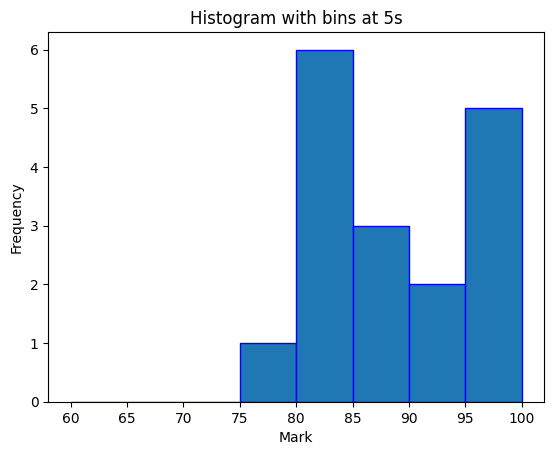

In [37]:
my_arr.plot.hist(bins = bins, edgecolor='blue')
plt.title('Histogram with bins at 5s')
plt.xlabel('Mark')
plt.ylabel('Frequency')
plt.show()

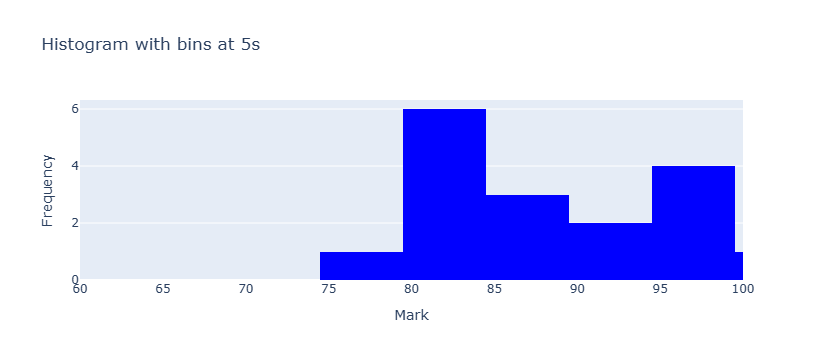

In [33]:
# OPTIONAL - Create histogram using Plotly Express
fig = px.histogram(my_arr, 
                   nbins=len(bins)-1, 
                   range_x=[min_val, 100],  
                   title='Histogram with bins at 5s',
                   labels={'value': 'Mark'},  
                   color_discrete_sequence=['blue'])  


fig.update_xaxes(title_text='Mark')
fig.update_yaxes(title_text='Frequency')


fig.update_layout(showlegend=False)

# Use template for the hover
fig.update_traces(hovertemplate='Mark: %{x}<br>Count: %{y}<extra></extra>')

fig.show()


In [43]:
# Calculate percentile rank for each mark
percentiles = my_arr.rank(pct=True)

# Combine into a DataFrame 
df = pd.DataFrame({'Mark': my_arr, 'Percentile': percentiles})
#print(df)

# Convert percentiles to a set (unique values only)
percentile_set = set(percentiles)

print(percentile_set)


# Count how many times each mark appears
mark_counts = my_arr.value_counts()
print(mark_counts)


# Unique marks as a set
mark_set = set(my_arr)
print(mark_set)


{0.8529411764705882, 1.0, 0.5294117647058824, 0.35294117647058826, 0.6764705882352942, 0.17647058823529413, 0.058823529411764705}
Python Test 1
96.0     4
84.0     3
88.0     3
80.0     3
92.0     2
100.0    1
76.0     1
Name: count, dtype: int64
{96.0, 100.0, 76.0, 80.0, 84.0, 88.0, 92.0}


In [53]:

def analyze_marks(arr, upper=101, step=5):
    # 1. Calculate bins
    val = arr.min() - 10
    min_val = math.floor(val / 10) * 10
    bins = list(range(min_val, upper, step))
    
    # 2. Calculate percentile ranks
    percentiles = arr.rank(pct=True)
    
    # 3. Count repetitions
    counts = arr.value_counts()
    
    # 4. Combine into DataFrame
    df = pd.DataFrame({
        'Mark': arr,
        'Percentile': percentiles,
        'Count': arr.map(counts)  # map count for each mark
    })
    
    return bins, df, counts

# Example usage:
#bins, df, counts = analyze_marks(my_arr)
# print("Bins:", bins)
# print("\nDataFrame:\n", df)
#print("\nCounts:\n", counts)



Counts:
 Python Test 1
96.0     4
84.0     3
88.0     3
80.0     3
92.0     2
100.0    1
76.0     1
Name: count, dtype: int64


SyntaxError: invalid syntax (1847756047.py, line 1)